In [5]:
%pip install opencv-python matplotlib

  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 465.6 kB/s eta 0:01:23
    --------------------------------------- 0.5/39.0 MB 465.6 kB/s eta 0:01:23
    --------------------------------------- 0.8/39.0 MB 472.8 kB/s eta 0:01:21
    --------------------------------------- 0.8/39.0 MB 472.8 kB/s eta 0:01:21
    --------------------------------------- 0.8/39.0 MB 472.8 kB/s eta 0:01:21
   - -------------------------------------- 1.0/39.0 MB 484.0 kB/s eta 0:01:19
   - ----------------------------

Note: you may need to restart the kernel to use updated packages.


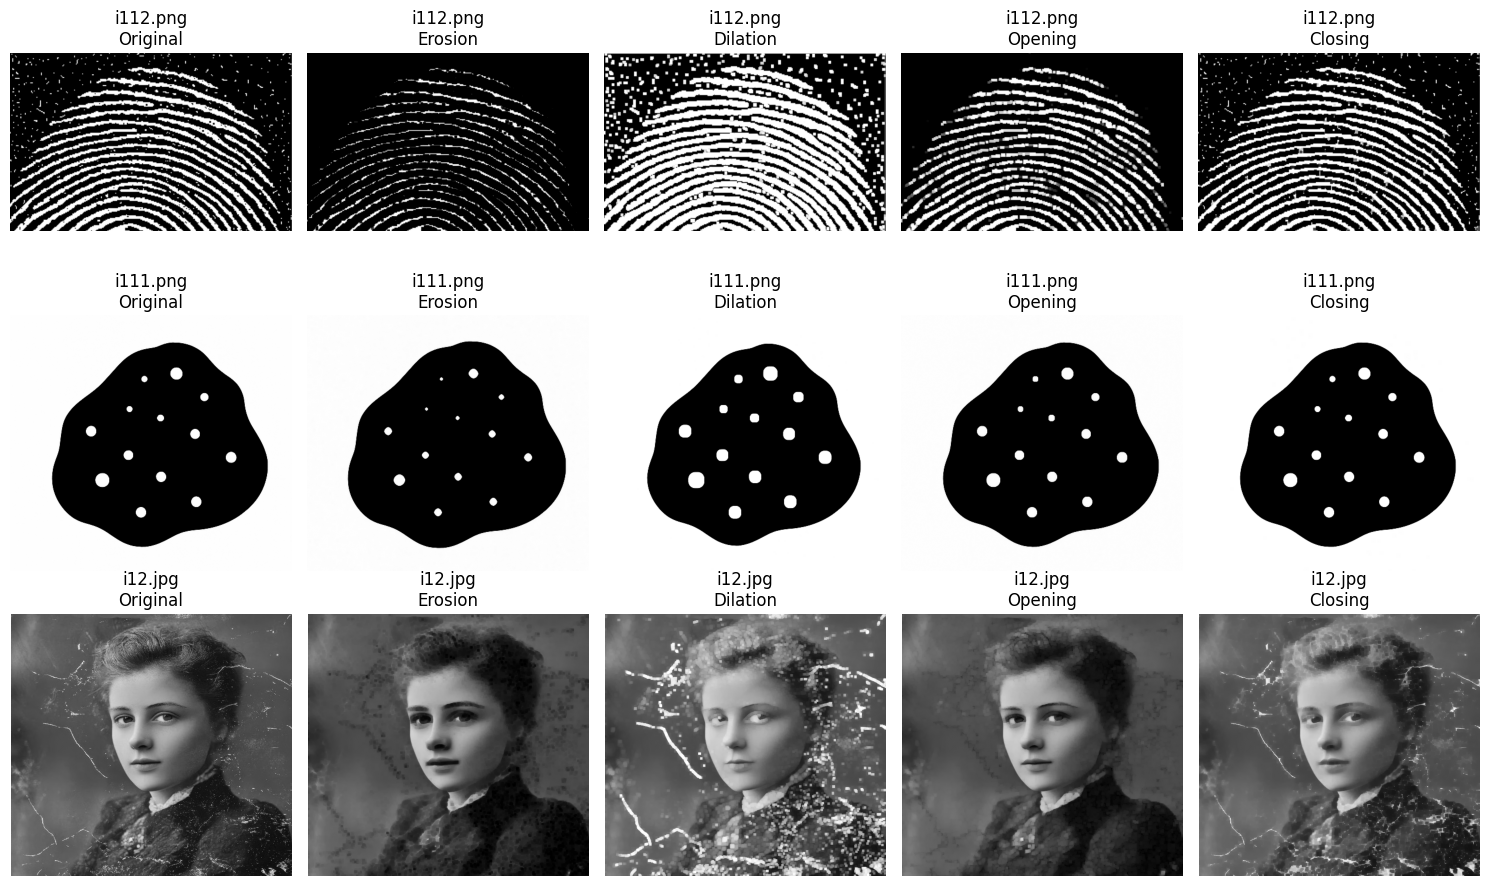

In [12]:
%pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

paths = [
    r'C:\Users\jhagh_xcgu3um\Desktop\SEM 5\DSIP\GitHub\DSIP\i112.png',
    r'C:\Users\jhagh_xcgu3um\Desktop\SEM 5\DSIP\GitHub\DSIP\i111.png',
    r'C:\Users\jhagh_xcgu3um\Desktop\SEM 5\DSIP\GitHub\DSIP\i12.jpg'
]

# Load images (grayscale) and check existence
images = []
for p in paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found: {p}")
    images.append(img)

# Kernel and morphological operations
kernel = np.ones((5, 5), np.uint8)
processed = []
for img in images:
    erosion = cv2.erode(img, kernel, iterations=1)
    dilation = cv2.dilate(img, kernel, iterations=1)
    opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    processed.append([img, erosion, dilation, opening, closing])

# Display: one row per image, columns = Original, Erosion, Dilation, Opening, Closing
titles = ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing']
nrows = len(processed)
ncols = len(titles)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = np.array(axes).reshape((nrows, ncols))  # ensure 2D array

for r, row in enumerate(processed):
    for c, im in enumerate(row):
        ax = axes[r, c]
        ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"{os.path.basename(paths[r])}\n{titles[c]}")
        ax.axis('off')

plt.tight_layout()
plt.show()


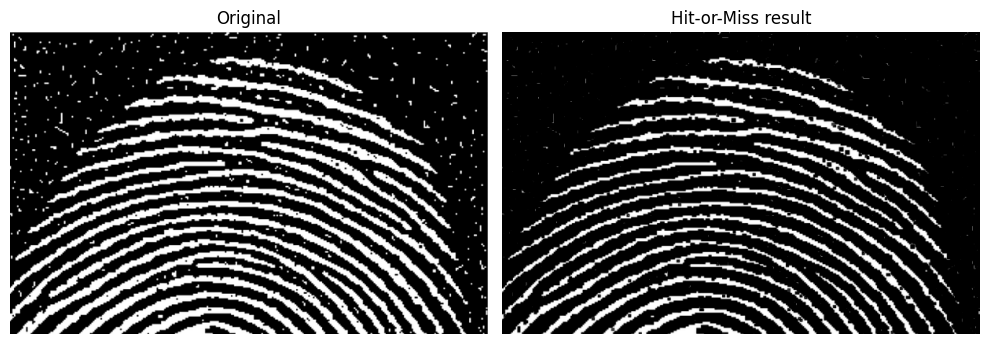

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load the binary image
image = cv2.imread(r'C:\Users\jhagh_xcgu3um\Desktop\SEM 5\DSIP\GitHub\DSIP\i112.png', 0)

# Define the structuring element for the pattern to be detected (0 for don't care, 1 for foreground, -1 for background)
pattern = np.array([[1, 1, 1],
                    [1, 0, 1],
                    [1, 1, 1]], dtype=np.int8)

# Apply the Hit or Miss Transformation
result = cv2.morphologyEx(image, cv2.MORPH_HITMISS, pattern)

# Display the original image and the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray', vmin=0, vmax=255)
plt.title('Hit-or-Miss result')
plt.axis('off')

plt.tight_layout()
plt.show()
cv2.waitKey(0)
cv2.destroyAllWindows()


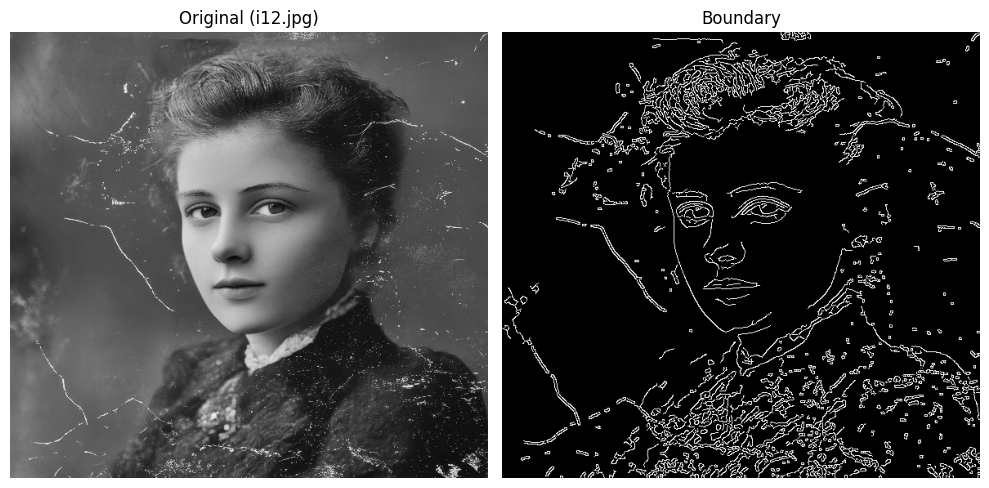

True

In [22]:
# Robust boundary extraction: try multiple candidate paths and avoid operating on None
import numpy as np

# Build list of candidate paths (original path, notebook variables if available)
candidate_paths = ['/content/Certificate 1698299913.jpg']
try:
	candidate_paths.append(p)   # use previously defined 'p' if available
except NameError:
	pass
try:
	candidate_paths.extend(paths)  # use 'paths' list from earlier cell if available
except NameError:
	pass

# Try to load the first readable image
image = None
source_path = None
for path in candidate_paths:
	if path is None:
		continue
	if os.path.exists(path):
		img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
		if img is not None:
			image = img
			source_path = path
			break

if image is None:
	raise FileNotFoundError(f"Could not load image. Tried: {candidate_paths}")

# Apply Gaussian blur to reduce noise
image_blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Apply Canny edge detection
edges = cv2.Canny(image_blurred, threshold1=30, threshold2=100)

# Create a black image with the same size as the original image
boundary_image = np.zeros_like(image)

# Copy the detected edges to the boundary image
boundary_image[edges > 0] = 255

# Display the original image and the boundary image using matplotlib (works in notebooks)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title(f'Original ({os.path.basename(source_path)})' if source_path else 'Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(boundary_image, cmap='gray', vmin=0, vmax=255)
plt.title('Boundary')
plt.axis('off')

plt.tight_layout()
plt.show()

# Save the boundary image
cv2.imwrite('boundary_image.jpg', boundary_image)
